In [1]:
from Tools.analysis_tools import *

In [2]:
# Percorso della cartella contenente i file CSV degli encoder
encoder_folder = "Encoder Analysis Data"

# Carica i dati
encoder_data = load_encoder_analysis_data(encoder_folder)


# Order the dataset
config_file = 'encoderDatabase.json'
enriched_data = enrich_analysis_with_config(encoder_data, config_file)

# Visualizza i dati caricati
print(encoder_data.head())


Caricando dati da: Encoder Analysis Data/30-20,15.csv
Caricando dati da: Encoder Analysis Data/30-20.csv
Caricando dati da: Encoder Analysis Data/Model_1.csv
Caricando dati da: Encoder Analysis Data/30-20,5.csv
Caricando dati da: Encoder Analysis Data/30-20,10.csv
Totale modelli caricati: 5
  Model Name  Latent Dim  Z2 R2 Mean  Z2 R2 Std  Z2 MSE Mean  Z2 MSE Std  \
0   30-20,15           5    0.793712   0.216734     0.013549    0.015559   
1      30-20           5    0.985236   0.025621     0.001146    0.002094   
2    Model_1           5    0.896108   0.179513     0.005819    0.009551   
3    30-20,5           5    0.958526   0.082981     0.002582    0.004744   
4   30-20,10           5    0.891746   0.166664     0.006499    0.010187   

   Z2 MaxSE Mean  Z2 MaxSE Std  \
0       0.077162      0.105536   
1       0.008700      0.021197   
2       0.034342      0.070602   
3       0.016456      0.038058   
4       0.035562      0.056785   

                                        PCA R2

In [3]:
# Lista dei filtri

'''
filter_type: equals o range
filter_value: valore del parametro (numero o range)
'''

filters = [
    {"param_name": "tau", "filter_type": "equals", "filter_value": 3},
    {"param_name": "alpha", "filter_type": "equals", "filter_value": 0}
]

filtered_data = filter_by_config_params(enriched_data, filters,False)
#print(filtered_data)

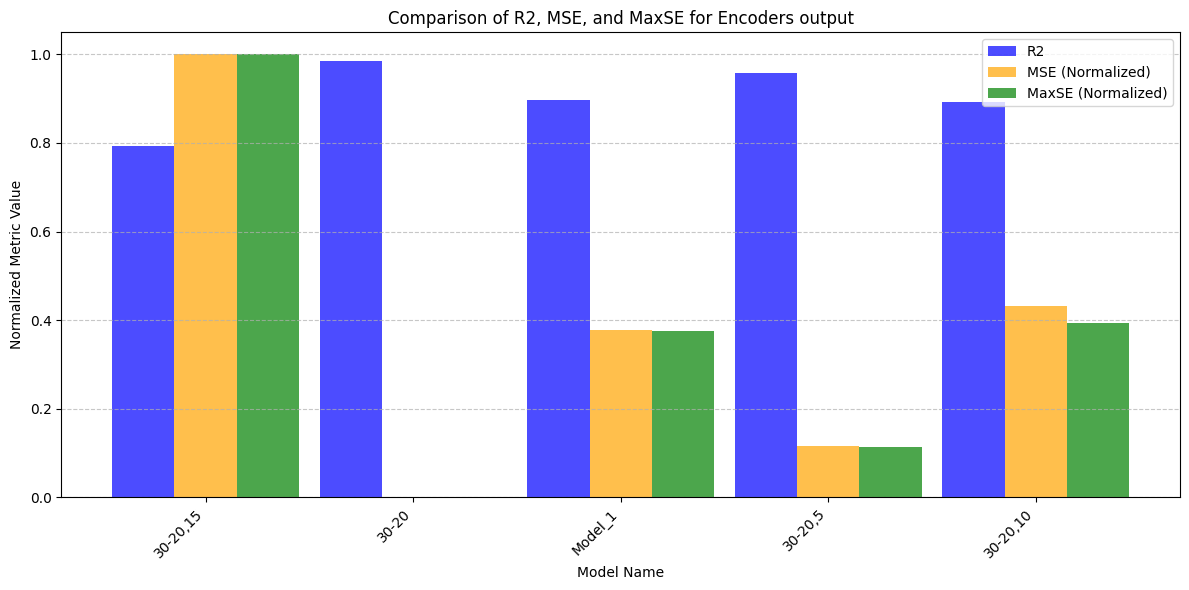

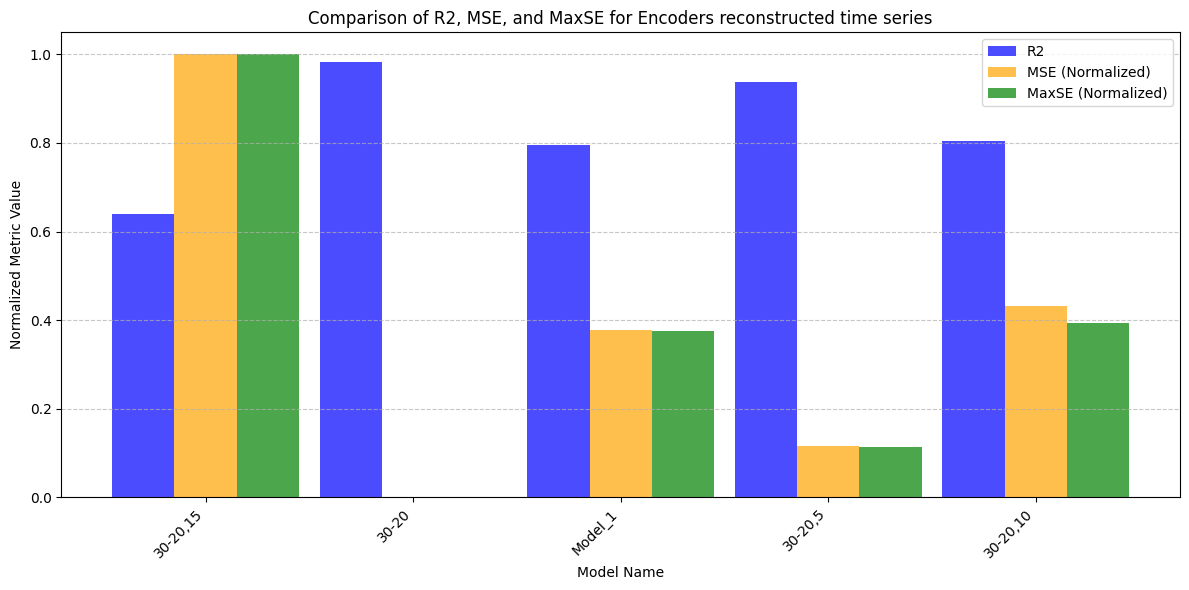

In [4]:
plot_z_metrics(
    data=filtered_data, 
    r2_col="Z2 R2 Mean", 
    mse_col="Z2 MSE Mean", 
    maxse_col="Z2 MaxSE Mean", 
    title="Comparison of R2, MSE, and MaxSE for Encoders output"
)
plot_z_metrics(
    data=filtered_data, 
    r2_col="PCA R2 Time Signal Z2", 
    mse_col="Z2 MSE Mean", 
    maxse_col="Z2 MaxSE Mean", 
    title="Comparison of R2, MSE, and MaxSE for Encoders reconstructed time series"
)

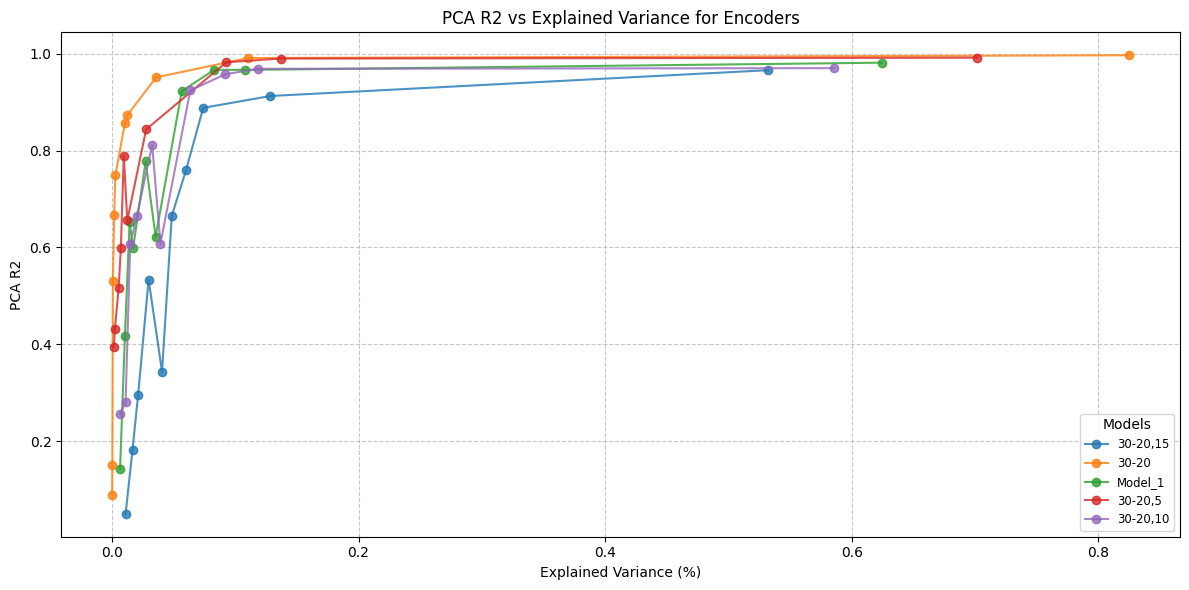

In [5]:
plot_pca_r2_and_variance(
    data=filtered_data,
    r2_col="PCA R2 Z2 PC",
    variance_col="Varianzce Explained Z2",
    title="PCA R2 vs Explained Variance for Encoders"
)


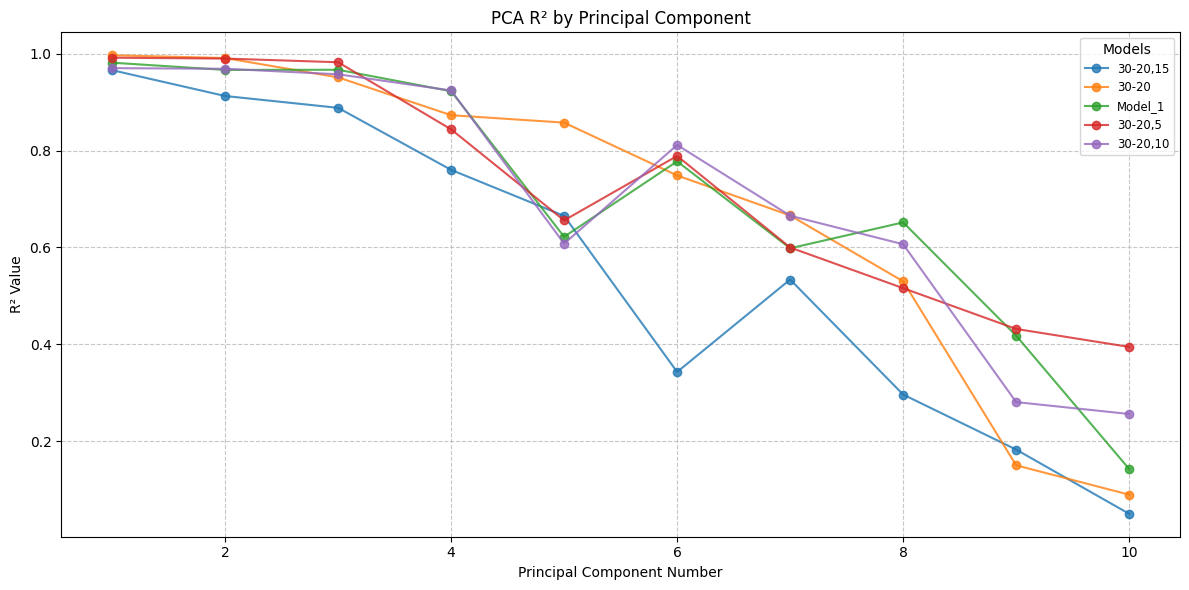

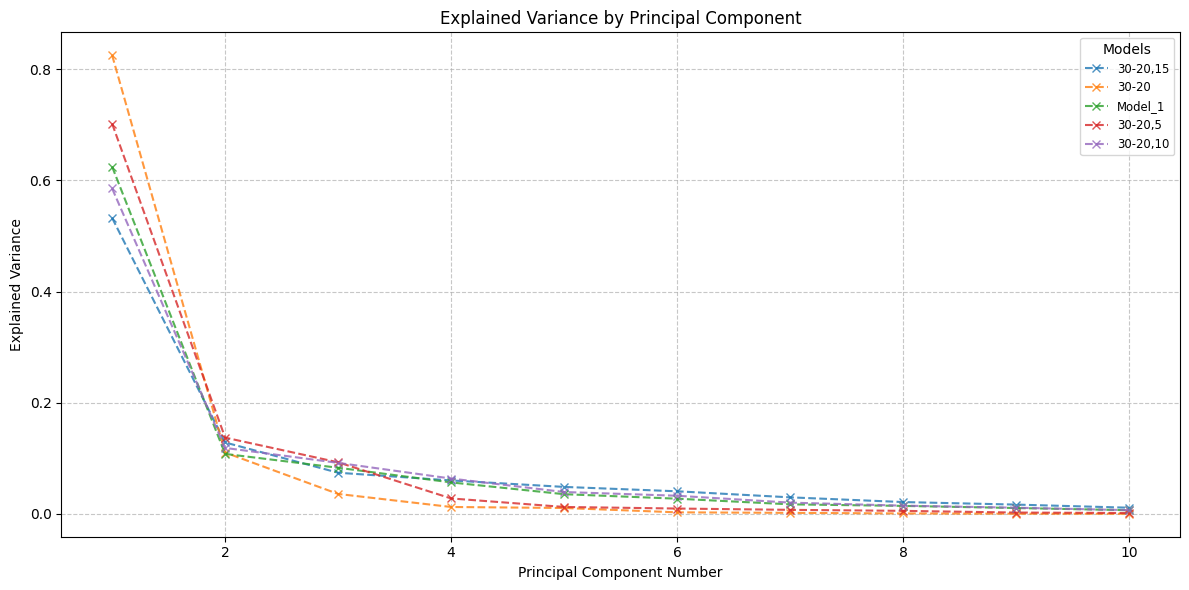

In [6]:
plot_r2_and_variance_separate(
    data=filtered_data, 
    r2_col="PCA R2 Z2 PC", 
    variance_col="Varianzce Explained Z2"
)

#Nota: La varianza spiegata è quasi sempre uguale (asse x)
